In [21]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import locale
import numpy as np
from math import sqrt
import statistics
import pprint

In [59]:
from math import nan


data = pd.read_csv("./datasets/titanic.csv")

# declaring x and y
x = data.drop(columns=["PassengerId", "Survived", "Name", "Ticket", "Fare", "Cabin", "Embarked"])
y = data["Survived"]

# numerizing data
x["Sex"] = x["Sex"].map({'male': 1, 'female': 0})
x["Age"] = x["Age"].replace({nan: round(x["Age"].mean())})

# variable for future use
dataset_count = len(y)
feature_count = len(x.iloc[0])

# making tensor x and y
x_tensor = torch.tensor(x.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)
y_tensor = y_tensor.unsqueeze(dim=1)

x_max = x_tensor.max(dim=0, keepdim=True).values

x_tensor = x_tensor / x_max

# making x scaled and clean
x_max_df = x_max.squeeze().tolist()
x_scaled = x.div(x_max_df, 1)

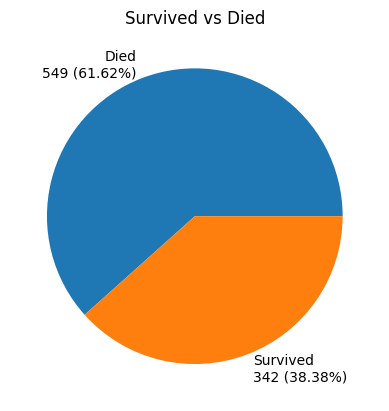

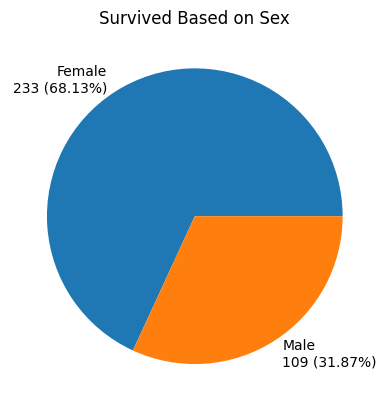

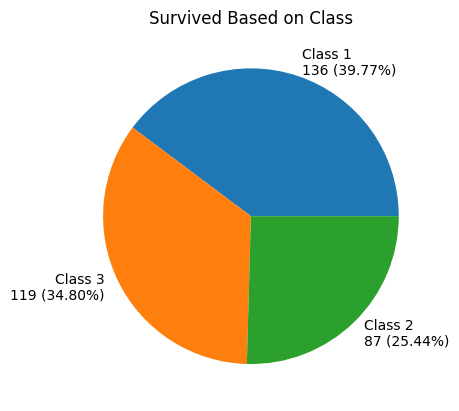

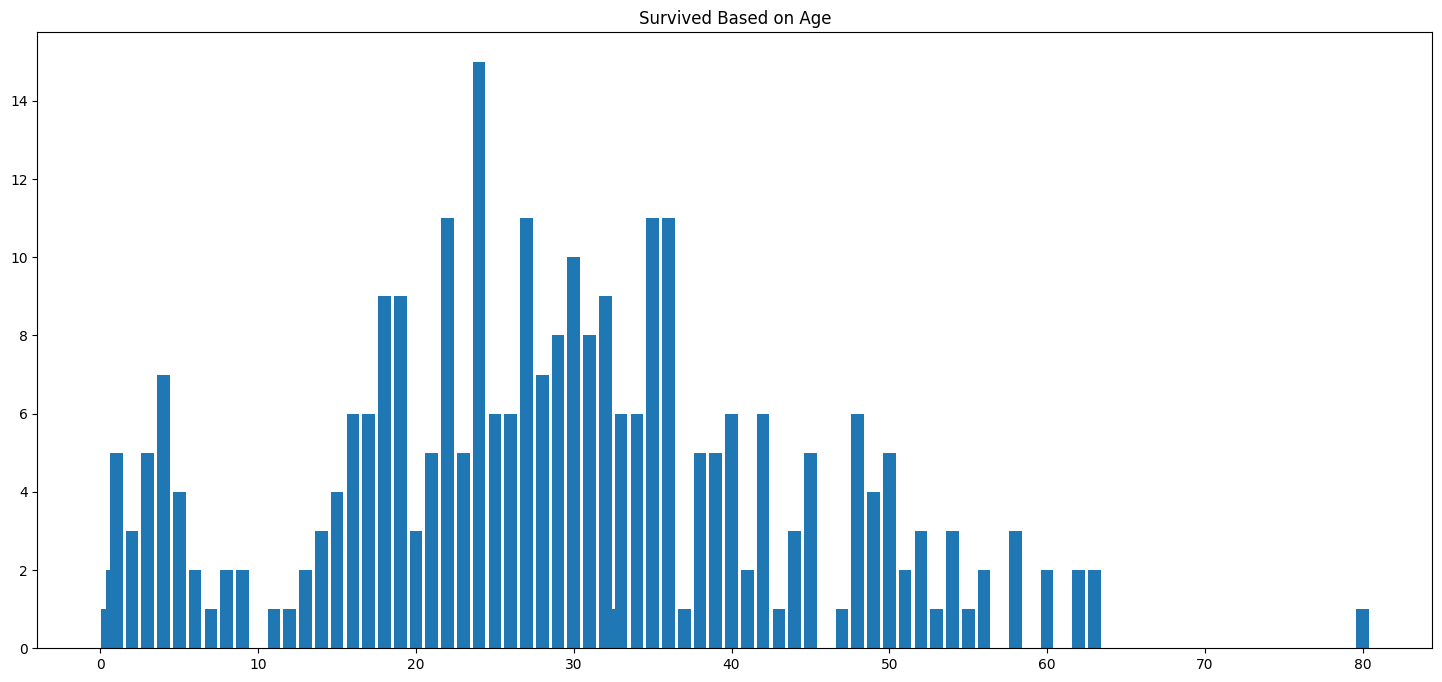

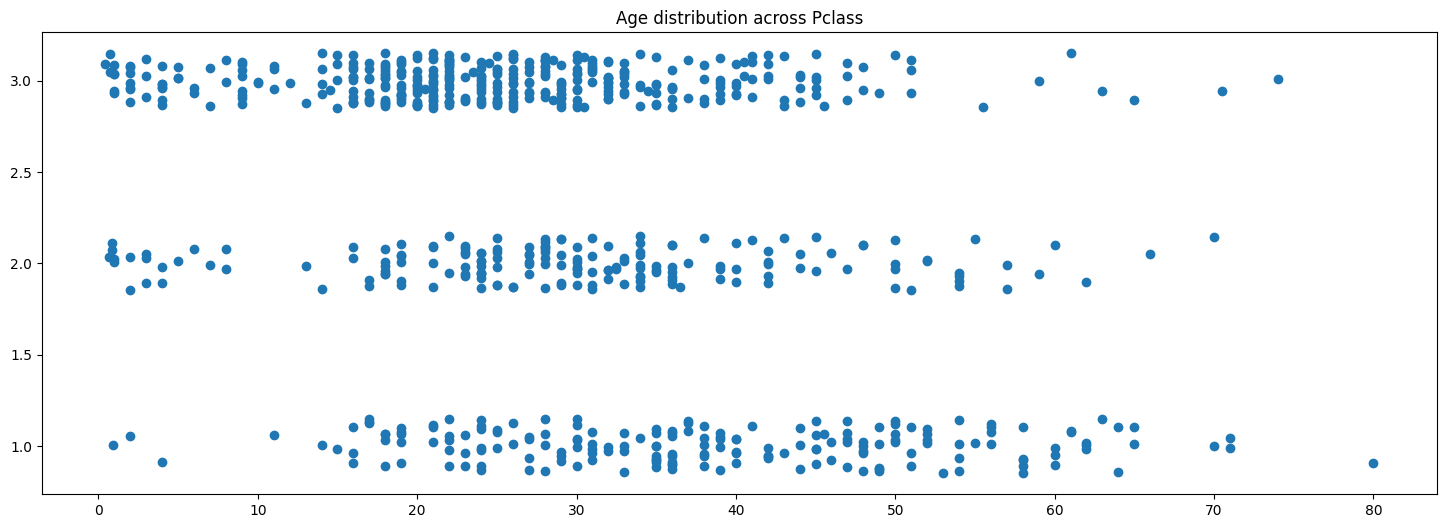

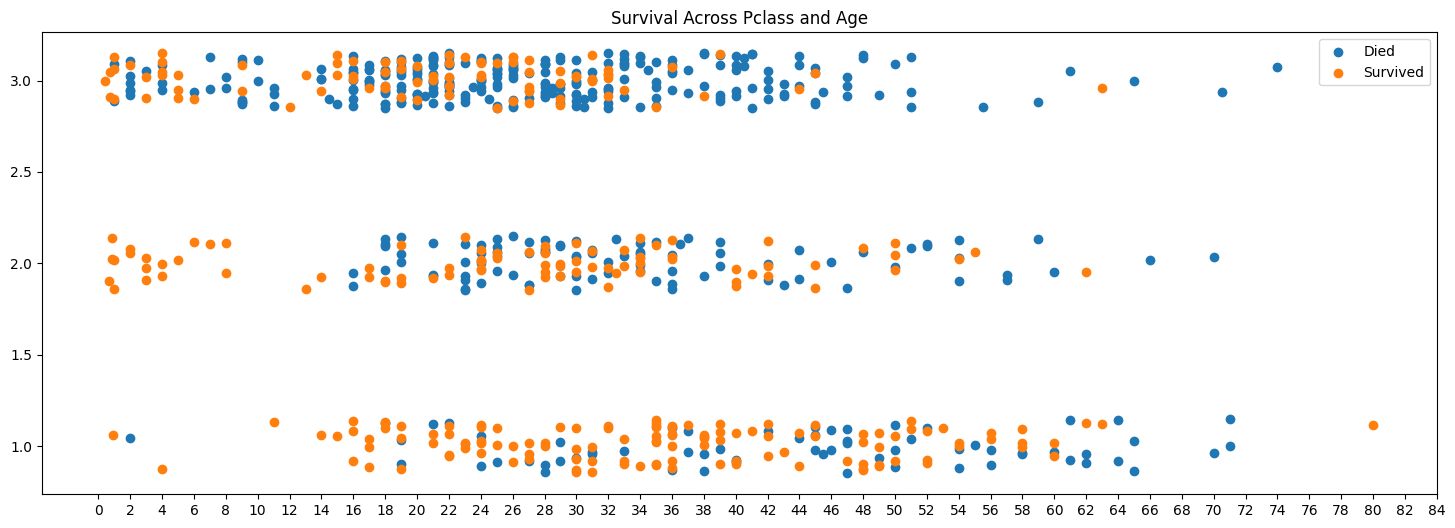

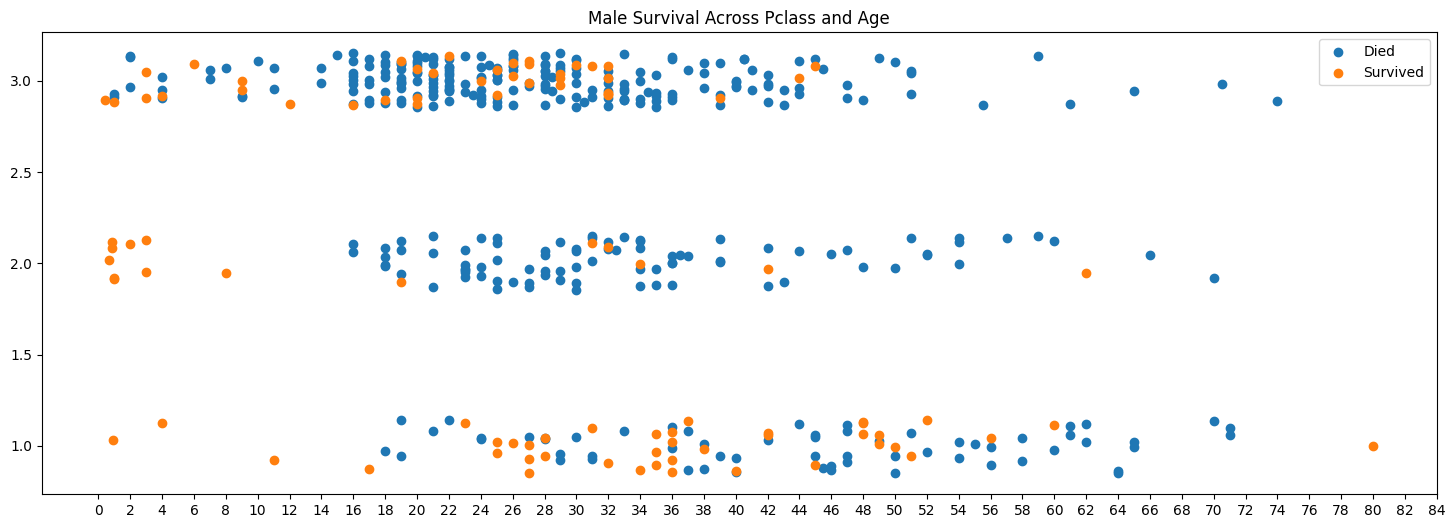

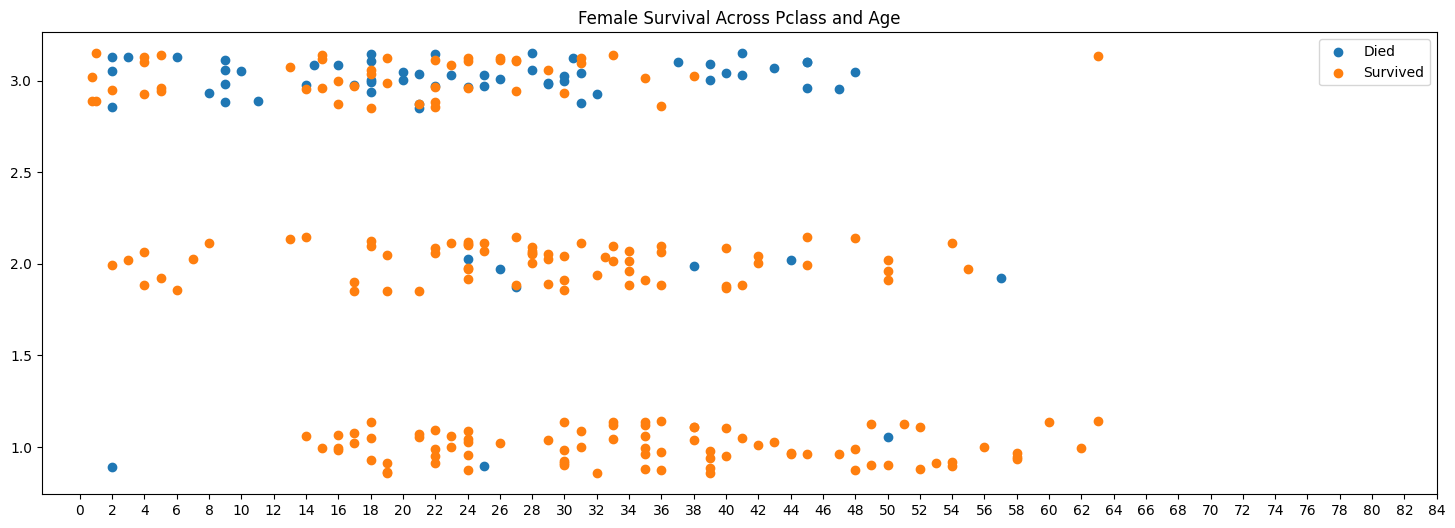

In [76]:
# data trend
def percentage(data, whole_list):
    return f"({(data / sum(whole_list) * 100):.2f}%)"

survived_value_counts = list(data["Survived"].value_counts())
plt.pie(survived_value_counts, labels=[f"Died\n{survived_value_counts[0]} {percentage(survived_value_counts[0], survived_value_counts)}", f"Survived\n{survived_value_counts[1]} {percentage(survived_value_counts[1], survived_value_counts)}"])
plt.title("Survived vs Died")
plt.show()

survived_sex_value_counts = list(((data[data["Survived"] == 1])["Sex"]).value_counts())
plt.pie(survived_sex_value_counts, labels=[f"Female\n{survived_sex_value_counts[0]} {percentage(survived_sex_value_counts[0], survived_sex_value_counts)}", f"Male\n{survived_sex_value_counts[1]} {percentage(survived_sex_value_counts[1], survived_sex_value_counts)}"])
plt.title("Survived Based on Sex")
plt.show()

survived_pclass_value_counts = list(((data[data["Survived"] == 1])["Pclass"]).value_counts())
plt.pie(survived_pclass_value_counts, labels=[f"Class 1\n{survived_pclass_value_counts[0]} {percentage(survived_pclass_value_counts[0], survived_pclass_value_counts)}", f"Class 3\n{survived_pclass_value_counts[1]} {percentage(survived_pclass_value_counts[1], survived_pclass_value_counts)}", f"Class 2\n{survived_pclass_value_counts[2]} {percentage(survived_pclass_value_counts[2], survived_pclass_value_counts)}"])
plt.title("Survived Based on Class")
plt.show()

survived_age_value_counts = ((data[data["Survived"] == 1])["Age"]).value_counts()
plt.figure(figsize=(18, 8))
plt.bar(survived_age_value_counts.index.tolist(), survived_age_value_counts.values.tolist())
plt.title("Survived Based on Age")
plt.show()

plt.figure(figsize=(18, 6))
pclass_list = data["Pclass"].tolist()
age_list = data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise)
plt.title("Age distribution across Pclass")
plt.show()

plt.figure(figsize=(18, 6))
died_data = data[data["Survived"] == 0]
pclass_list = died_data["Pclass"].tolist()
age_list = died_data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise, label="Died")
survived_data = data[data["Survived"] == 1]
pclass_list = survived_data["Pclass"].tolist()
age_list = survived_data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise, label="Survived")
plt.title("Survival Across Pclass and Age")
plt.xticks(np.arange(0, 86, 2))
plt.legend()
plt.show()

plt.figure(figsize=(18, 6))
died_data = data[(data["Survived"] == 0) & (data["Sex"] == "male")]
pclass_list = died_data["Pclass"].tolist()
age_list = died_data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise, label="Died")
survived_data = data[(data["Survived"] == 1) & (data["Sex"] == "male")]
pclass_list = survived_data["Pclass"].tolist()
age_list = survived_data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise, label="Survived")
plt.title("Male Survival Across Pclass and Age")
plt.xticks(np.arange(0, 86, 2))
plt.legend()
plt.show()

plt.figure(figsize=(18, 6))
died_data = data[(data["Survived"] == 0) & (data["Sex"] == "female")]
pclass_list = died_data["Pclass"].tolist()
age_list = died_data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise, label="Died")
survived_data = data[(data["Survived"] == 1) & (data["Sex"] == "female")]
pclass_list = survived_data["Pclass"].tolist()
age_list = survived_data["Age"].tolist()
noise = np.random.uniform(-0.15, 0.15, size=len(age_list))
plt.scatter(age_list, pclass_list + noise, label="Survived")
plt.title("Female Survival Across Pclass and Age")
plt.xticks(np.arange(0, 86, 2))
plt.legend()
plt.show()

## Model 1: Neural Network

In [7]:
class Classification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(feature_count, feature_count ** 2)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(feature_count ** 2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.sigmoid(x)
        return x
    
model = Classification()
loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-2)

In [8]:
for epoch in range(5000):
    output = model(x_tensor)
    
    l = loss(output, y_tensor)
    
    l.backward()
    
    optimizer.step()
    optimizer.zero_grad()
    
    print(f"epoch {epoch} = loss: {l}")

epoch 0 = loss: 0.6812326312065125
epoch 1 = loss: 0.6393471956253052
epoch 2 = loss: 0.6237900257110596
epoch 3 = loss: 0.6076660752296448
epoch 4 = loss: 0.5886715650558472
epoch 5 = loss: 0.5698785185813904
epoch 6 = loss: 0.5513145327568054
epoch 7 = loss: 0.5325063467025757
epoch 8 = loss: 0.5144476294517517
epoch 9 = loss: 0.5000090599060059
epoch 10 = loss: 0.4900474548339844
epoch 11 = loss: 0.4842897057533264
epoch 12 = loss: 0.4813711643218994
epoch 13 = loss: 0.4792771339416504
epoch 14 = loss: 0.47550854086875916
epoch 15 = loss: 0.46940046548843384
epoch 16 = loss: 0.4621807634830475
epoch 17 = loss: 0.45595553517341614
epoch 18 = loss: 0.45167914032936096
epoch 19 = loss: 0.4492105543613434
epoch 20 = loss: 0.4486313760280609
epoch 21 = loss: 0.44849222898483276
epoch 22 = loss: 0.44767317175865173
epoch 23 = loss: 0.445913165807724
epoch 24 = loss: 0.4430942237377167
epoch 25 = loss: 0.43943968415260315
epoch 26 = loss: 0.4360445737838745
epoch 27 = loss: 0.4334512054920

In [45]:
pclass = 1
sex = 1
age = 18
sibSp = 0
parch = 0

test_data = torch.tensor([pclass, sex, age, sibSp, parch], dtype=torch.float32) / x_max

alive_prob = int(model(test_data)[0, 0].tolist() * 100)

print(f"survive probability: {alive_prob}%")

survive probability: 8%


## Model 2: K-Nearest Neighbor (KNN)

In [10]:
# X is a matrix
# Y is a matrix
# x_new is a vector
# k is how many data took part in the decision

def KNN(x, y, x_new, k):
    distances = []
    
    for sample_index in range(len(x)):
        distance = 0
        
        for feature_index in range(len(x.iloc[sample_index])):
            distance += (x.iloc[sample_index, feature_index] - x_new.iloc[feature_index]) ** 2
            
        distance = sqrt(distance)
        distances.append([sample_index, distance])
    
    distances.sort(key=lambda x: x[1])
    
    distances = distances[0:k]
    
    nearest_indexes = [row[0] for row in distances]
    
    votes = []
    
    for nearest_index in nearest_indexes:
        votes.append(int(y.iloc[nearest_index]))
    
    winner = statistics.mode(votes)
        
    voter_data = (x.iloc[nearest_indexes]).mul(x_max_df, 1)
    
    voter_data["Survived"] = votes
    
    voter_data["Sex"] = voter_data["Sex"].replace({0: "female", 1: "male"})
    voter_data["Survived"] = voter_data["Survived"].replace({0: "no", 1: "yes"})
    
    return {
        "Alive": True if winner == 1 else False,
        "Neighbors": voter_data
    }

In [81]:
pclass = 1
sex = 1
age = 18
sibSp = 0
parch = 0

test_data = pd.Series([pclass, sex, age, sibSp, parch]).div(x_max_df)

result = KNN(x_scaled, y, test_data, 5)
print("Survived:", result["Alive"], "\n")
print("Nearest Neighbors \n", result["Neighbors"])

Survived: True 

Nearest Neighbors 
      Pclass   Sex   Age  SibSp  Parch Survived
373     1.0  male  22.0    0.0    0.0       no
139     1.0  male  24.0    0.0    0.0       no
889     1.0  male  26.0    0.0    0.0      yes
607     1.0  male  27.0    0.0    0.0      yes
681     1.0  male  27.0    0.0    0.0      yes
